In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time
from astropy.io import fits
from scipy.signal import find_peaks
import plotly.graph_objects as go

folder = '/Users/lyniya/Downloads/KPF Spectra (Aug 8-10 reprocessed)'
data_0808_cubic = np.load(f'{folder}/socal_spectra_20240808_SCI2_cubic.npz')
wave_0808_cubic, flux_0808_cubic, eflux_0808_cubic, bjd_0808_cubic = data_0808_cubic['wave'], data_0808_cubic['flux'], data_0808_cubic['eflux'], data_0808_cubic['bjd']

ref_spec = np.load('/Users/lyniya/Downloads/normalized_kpf_solar_spectrum.npz')
ref_flux = ref_spec['flux']
ref_wave = ref_spec['wave']

telluric_model = fits.open('/Users/lyniya/Downloads/TAPAS_WMKO_NORAYLEIGH_SPEC.fits')[0].data
telluric_wave = fits.open('/Users/lyniya/Downloads/TAPAS_WMKO_NORAYLEIGH_SPEC_WVL.fits')[0].data
telwave = telluric_wave * 10
telflux = telluric_model

times_0808_cubic = Time(bjd_0808_cubic, format='jd', scale='tdb').to_datetime()
flare_start = Time('2024-08-08 19:01:00', format='iso', scale='utc').to_datetime(timezone=times_0808_cubic[0].tzinfo)
flare_peak_goes = Time('2024-08-08 19:35:00', format='iso', scale='utc').to_datetime(timezone=times_0808_cubic[0].tzinfo)
flare_end = Time('2024-08-08 19:57:00', format='iso', scale='utc').to_datetime(timezone=times_0808_cubic[0].tzinfo)

print('Aug 8:', flux_0808_cubic.shape)

Aug 8: (150, 67, 4080)


In [ ]:
# H alpha

In [2]:
order = 43
w = ref_wave[order, :]
f = ref_flux[order, :]

target_wave = 6562.8  # Hα rest wavelength

peaks, _ = find_peaks(-f, distance=5, prominence=0.01)
max_peaks, _ = find_peaks(f, distance=5, prominence=0.01)

peak = peaks[np.argmin(np.abs(w[peaks] - target_wave))]
left_maxima = max_peaks[max_peaks < peak]
right_maxima = max_peaks[max_peaks > peak]
left_bound = left_maxima[-1] if len(left_maxima) > 0 else 0
right_bound = right_maxima[0] if len(right_maxima) > 0 else len(f) - 1

print('peak pixel:', peak, 'wave:', w[peak])
print('left_bound:', left_bound, 'right_bound:', right_bound)

peak pixel: 3456 wave: 6562.929912273356
left_bound: 3455 right_bound: 3461


In [25]:
order = 43
w = ref_wave[order, :]
f = ref_flux[order, :]

target_wave = 6564.612

peaks, _ = find_peaks(-f, distance=5, prominence=0.01)
max_peaks, _ = find_peaks(f, distance=5, prominence=0.01)

peak = peaks[np.argmin(np.abs(w[peaks] - target_wave))]
left_maxima = max_peaks[max_peaks < peak]
right_maxima = max_peaks[max_peaks > peak]
left_bound = left_maxima[-1] if len(left_maxima) > 0 else 0
right_bound = right_maxima[0] if len(right_maxima) > 0 else len(f) - 1


In [ ]:
# Pre Flare Reference 

In [5]:
preflare = np.arange(len(times_0808_cubic)) < 11

def preflareref(wave, flux, eflux, order, preflare):
    wave_ref = wave[order, :]
    flux_ref = np.nanmean(flux[preflare, order, :], axis=0)
    f_err_ref = np.sqrt(np.nansum(eflux[preflare, order, :]**2, axis=0)) / preflare.sum()
    return wave_ref, flux_ref, f_err_ref

wave_ref, flux_ref, f_err_ref = preflareref(wave_0808_cubic, flux_0808_cubic, eflux_0808_cubic, order, preflare)

In [ ]:
# Divide

In [6]:
def divideflux(wave, flux, eflux, order, wave_ref, flux_ref, f_err_ref):
    wave_F = wave[order, :]
    f = flux[:, order, :]
    sigma_f = eflux[:, order, :]
    F = f / flux_ref
    sigma_F = F * np.sqrt((sigma_f / f)**2 + (f_err_ref / flux_ref)**2)
    return wave_F, F, sigma_F

wave_F, F, sigma_F = divideflux(wave_0808_cubic, flux_0808_cubic, eflux_0808_cubic, order, wave_ref, flux_ref, f_err_ref)

In [ ]:
# Integrate Flux

In [7]:
def integrateflux(wave_F, F, sigma_F, core_min, core_max):
    core = (wave_F >= core_min) & (wave_F <= core_max)
    x = wave_F[core]
    y = F[:, core]
    sigma_y = sigma_F[:, core]
    Y = np.trapezoid(y, x, axis=1)
    sigma_Y = np.sqrt(np.sum((sigma_y * np.gradient(x))**2, axis=1))
    return Y, sigma_Y

In [ ]:
# Width stuff

In [10]:
max_hw = min(peak - left_bound, right_bound - peak)

widths = []
peak_response = []
Y_by_width = []
sigma_Y_by_width = []

for hw in range(1, max_hw + 1):
    left = peak - hw
    right = peak + hw
    core_min = w[left]
    core_max = w[right]

    Y, sigma_Y = integrateflux(wave_F, F, sigma_F, core_min, core_max)
    core_width = core_max - core_min
    Y = Y / core_width
    sigma_Y = sigma_Y / core_width
    Y_baseline = Y[preflare].mean()
    Y = Y / Y_baseline
    sigma_Y = sigma_Y / Y_baseline

    widths.append(core_width)
    peak_response.append(Y.max() - 1)
    Y_by_width.append(Y)
    sigma_Y_by_width.append(sigma_Y)

In [32]:
left_px = 45
right_px = 45

left = peak - left_px
right = peak + right_px

core_min = w[left]
core_max = w[right]

Y, sigma_Y = integrateflux(wave_F, F, sigma_F, core_min, core_max)
core_width = core_max - core_min
Y = Y / core_width
sigma_Y = sigma_Y / core_width
Y_baseline = Y[preflare].mean()
Y = Y / Y_baseline
sigma_Y = sigma_Y / Y_baseline

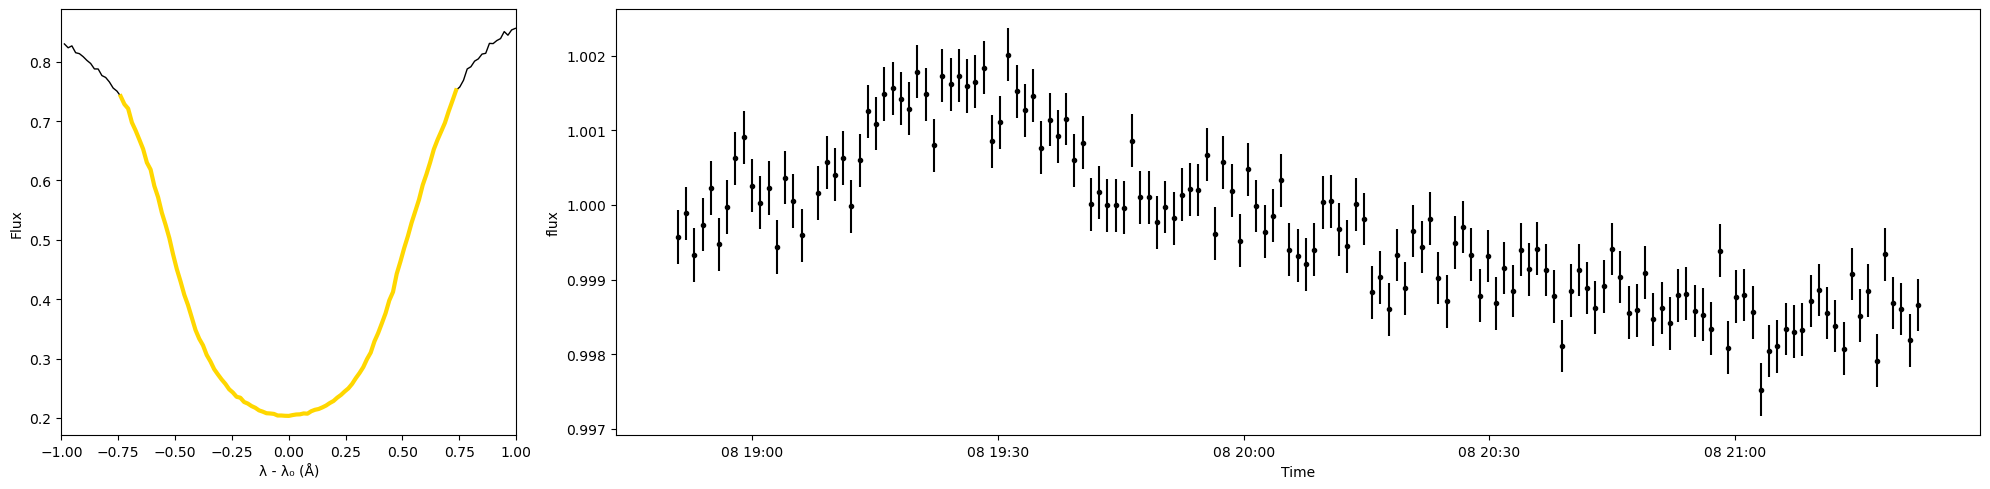

In [33]:
fig, (spec_ax, lc_ax) = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 3]})

dwave = 1
zoom_sel = (w > target_wave - dwave) & (w < target_wave + dwave)
spec_ax.plot(w[zoom_sel] - target_wave, f[zoom_sel], 'k-', linewidth=1)
spec_ax.plot(w[left:right+1] - target_wave, f[left:right+1], color='gold', linewidth=3)
spec_ax.set(xlim=[-dwave, dwave], xlabel='λ - λ₀ (Å)', ylabel='Flux')

lc_ax.errorbar(times_0808_cubic, Y, yerr=sigma_Y, fmt='.', color='black')
lc_ax.set(xlabel='Time', ylabel='flux')

plt.tight_layout()
plt.show()